In [8]:
import os
import numpy as np
import random
import warnings
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from skopt import BayesSearchCV
from skopt.space import Integer, Real

# 固定随机种子
os.environ['PYTHONHASHSEED'] = str(1)
np.random.seed(1)
random.seed(1)
warnings.filterwarnings("ignore")

# 1. 数据加载
data = pd.read_excel('dataset.xlsx')
data.rename(columns={"C0": r"C$_0$"}, inplace=True) 

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# 确保数据为数值型
if not np.issubdtype(X.dtypes, np.number):
    X = X.apply(pd.to_numeric, errors='coerce')
if not np.issubdtype(y.dtype, np.number):
    y = pd.to_numeric(y, errors='coerce')

# 检查 NaN/Inf
if X.isnull().any().any() or y.isnull().any():
    raise ValueError("Dataset contains invalid values (NaN or inf). Please check your data.")

# 2. 数据预处理
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.3, random_state=1
)

# 3. 参数优化 (Bayesian Optimization)
gbdt_model = GradientBoostingRegressor(random_state=1)

param_spaces = {
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'max_depth': Integer(3, 10),
    'n_estimators': Integer(100, 300),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 10),
    'subsample': Real(0.5, 1.0, prior='uniform')
}

optimizer = BayesSearchCV(
    estimator=gbdt_model,
    search_spaces=param_spaces,
    n_iter=32,
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=1
)

optimizer.fit(X_train, y_train)

# 4. 用最优参数训练
best_params = optimizer.best_params_
print(f'Best parameters: {best_params}')
gbdt_optimized = GradientBoostingRegressor(**best_params, random_state=1)
gbdt_optimized.fit(X_train, y_train)

# 5. 模型评估
def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    metrics = {
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'Train R^2': r2_score(y_train, y_pred_train),
        'Test R^2': r2_score(y_test, y_pred_test),
        'Train MAE': mean_absolute_error(y_train, y_pred_train),
        'Test MAE': mean_absolute_error(y_test, y_pred_test)
    }
    return metrics

results = evaluate_model(gbdt_optimized, X_train, X_test, y_train, y_test)
for metric, value in results.items():
    print(f'{metric}: {value}')

# # 6. 导出结果
# def export_results(y_train, y_pred_train, y_test, y_pred_test, filename='Results_GBDT.xlsx'):
#     with pd.ExcelWriter(filename) as writer:
#         train_results_df = pd.DataFrame({'y_true': y_train, 'y_pred': y_pred_train})
#         test_results_df = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred_test})

#         train_results_df.to_excel(writer, sheet_name='Train Results', index=False)
#         test_results_df.to_excel(writer, sheet_name='Test Results', index=False)

# export_results(
#     y_train,
#     gbdt_optimized.predict(X_train),
#     y_test,
#     gbdt_optimized.predict(X_test)
# )


Best parameters: OrderedDict([('learning_rate', 0.12201912010720624), ('max_depth', 3), ('min_samples_leaf', 1), ('min_samples_split', 10), ('n_estimators', 300), ('subsample', 0.5784499501019427)])
Train RMSE: 0.48921521929718836
Test RMSE: 3.843956870846838
Train R^2: 0.9998446625771079
Test R^2: 0.9913690965879417
Train MAE: 0.40172935581089975
Test MAE: 2.27873920163828


In [3]:
import joblib

# 保存模型
joblib.dump(gbdt_optimized, 'GBDT.pkl')
print("模型已保存为 GBDT.pkl")

模型已保存为 GBDT.pkl


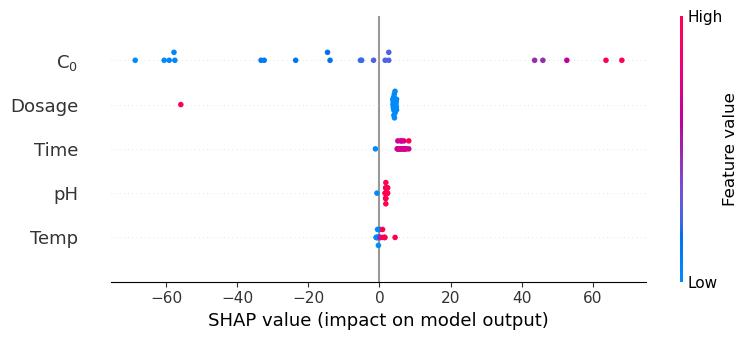

In [9]:
import shap
import matplotlib.pyplot as plt

# 使用 CatBoost 模型初始化 SHAP explainer
explainer = shap.TreeExplainer(gbdt_optimized)

# 计算 SHAP 值（使用未缩放的特征更易解释）
shap_values = explainer.shap_values(X_test)

# 可视化 summary plot
shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)

# 保存高清图像（600 dpi）
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=600, bbox_inches='tight',)
plt.show()


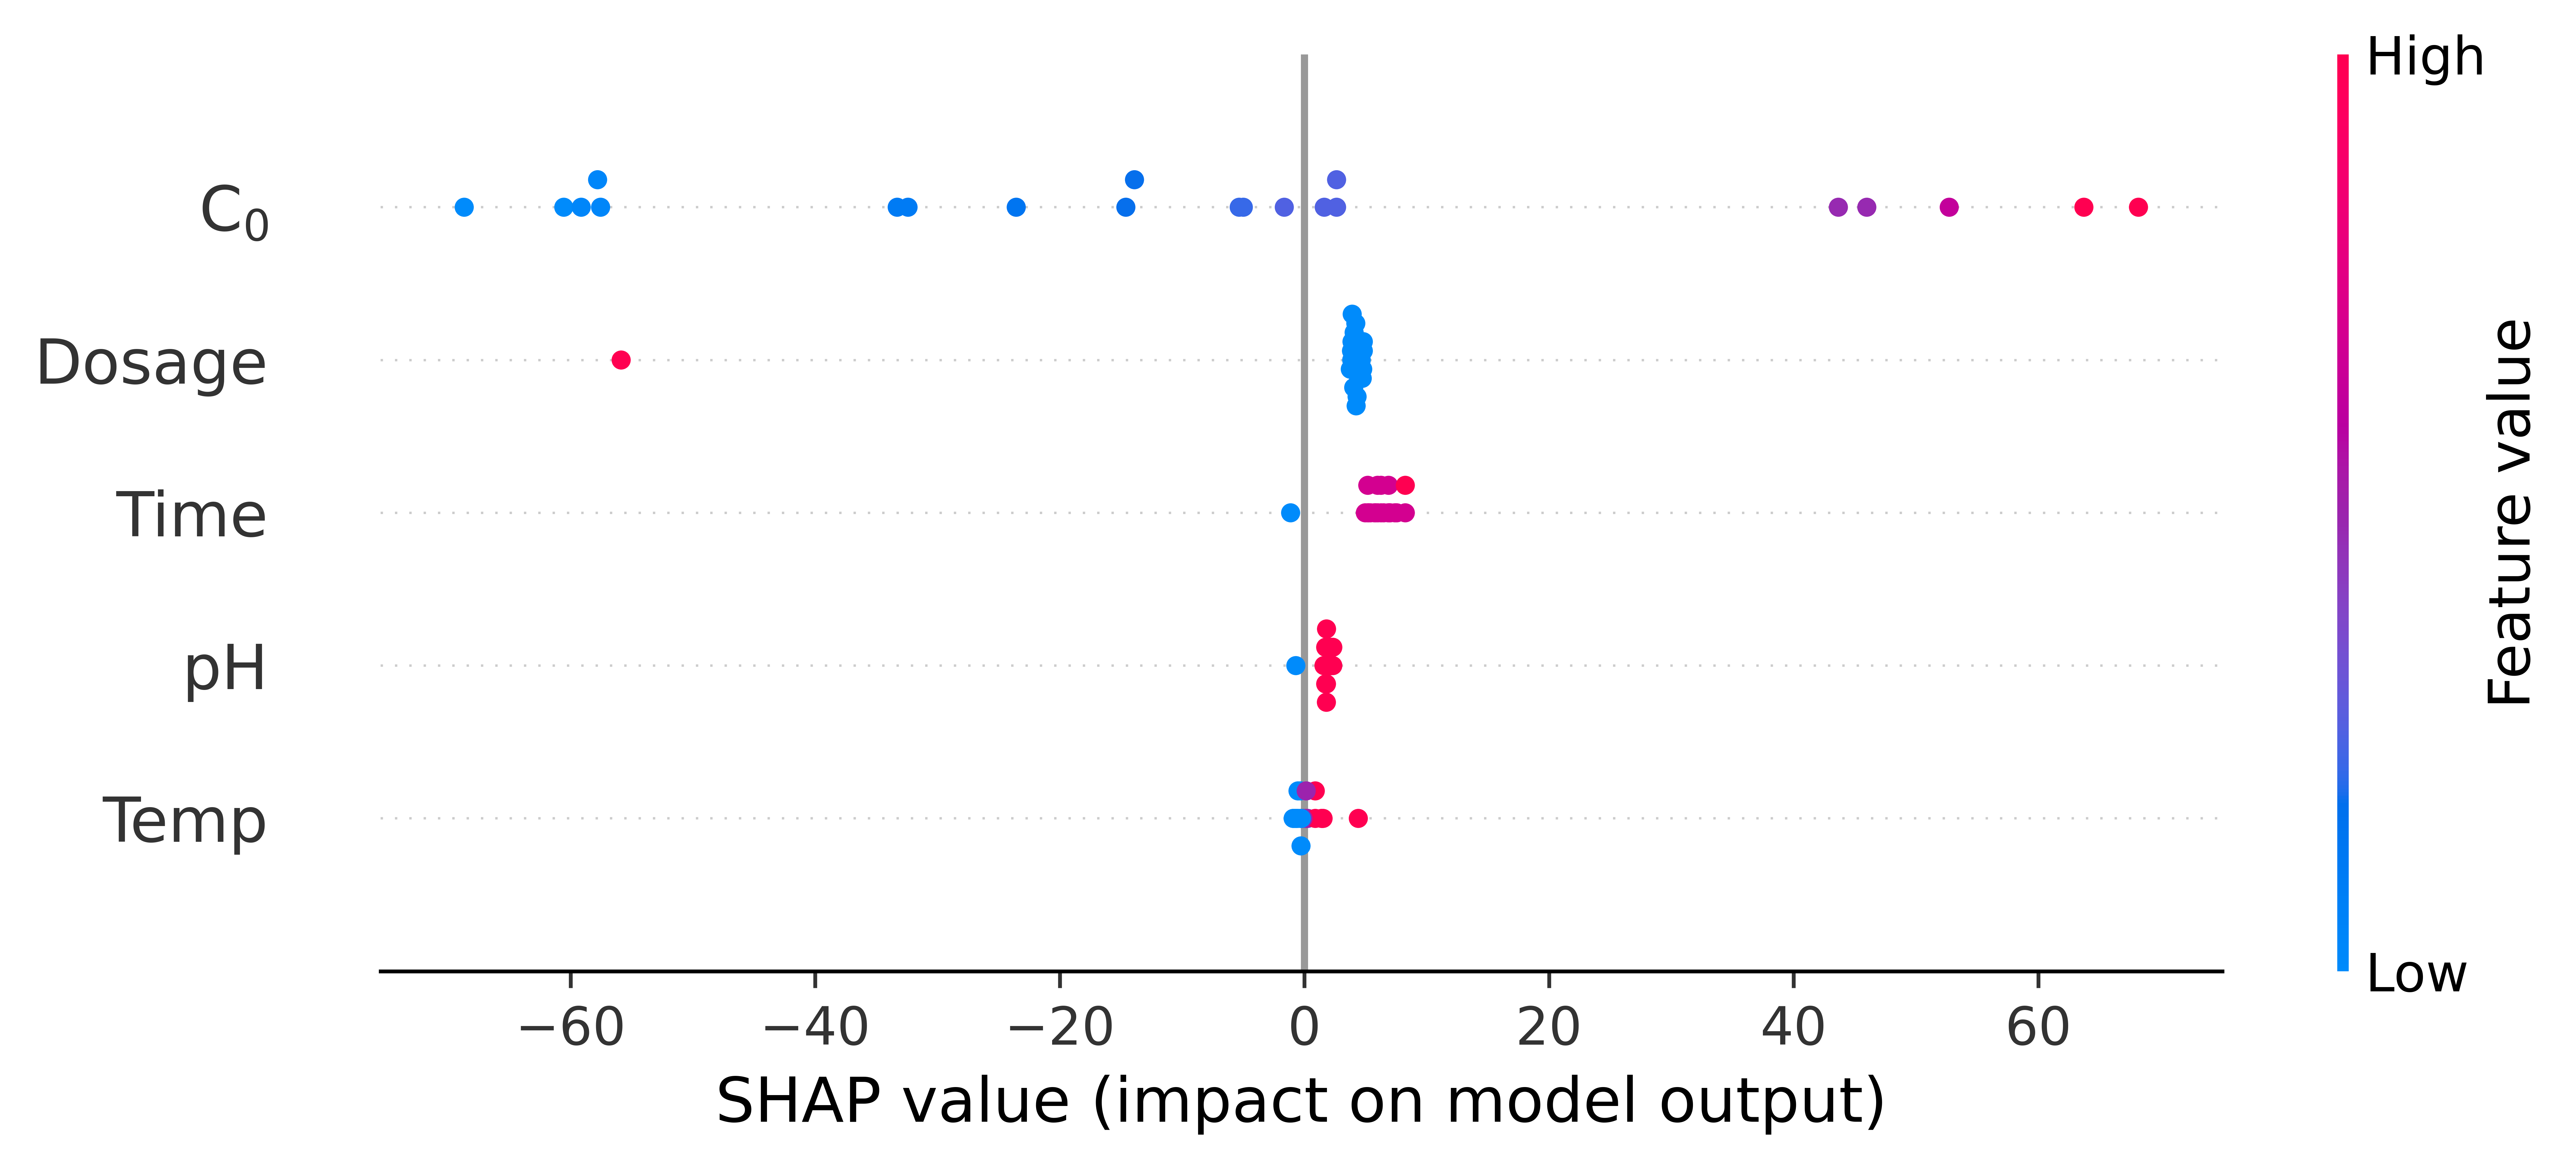

In [10]:
plt.figure(figsize=(10, 5), dpi=1200)
shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)
plt.tight_layout()
plt.savefig("1.pdf", format='pdf',bbox_inches='tight')
plt.show()

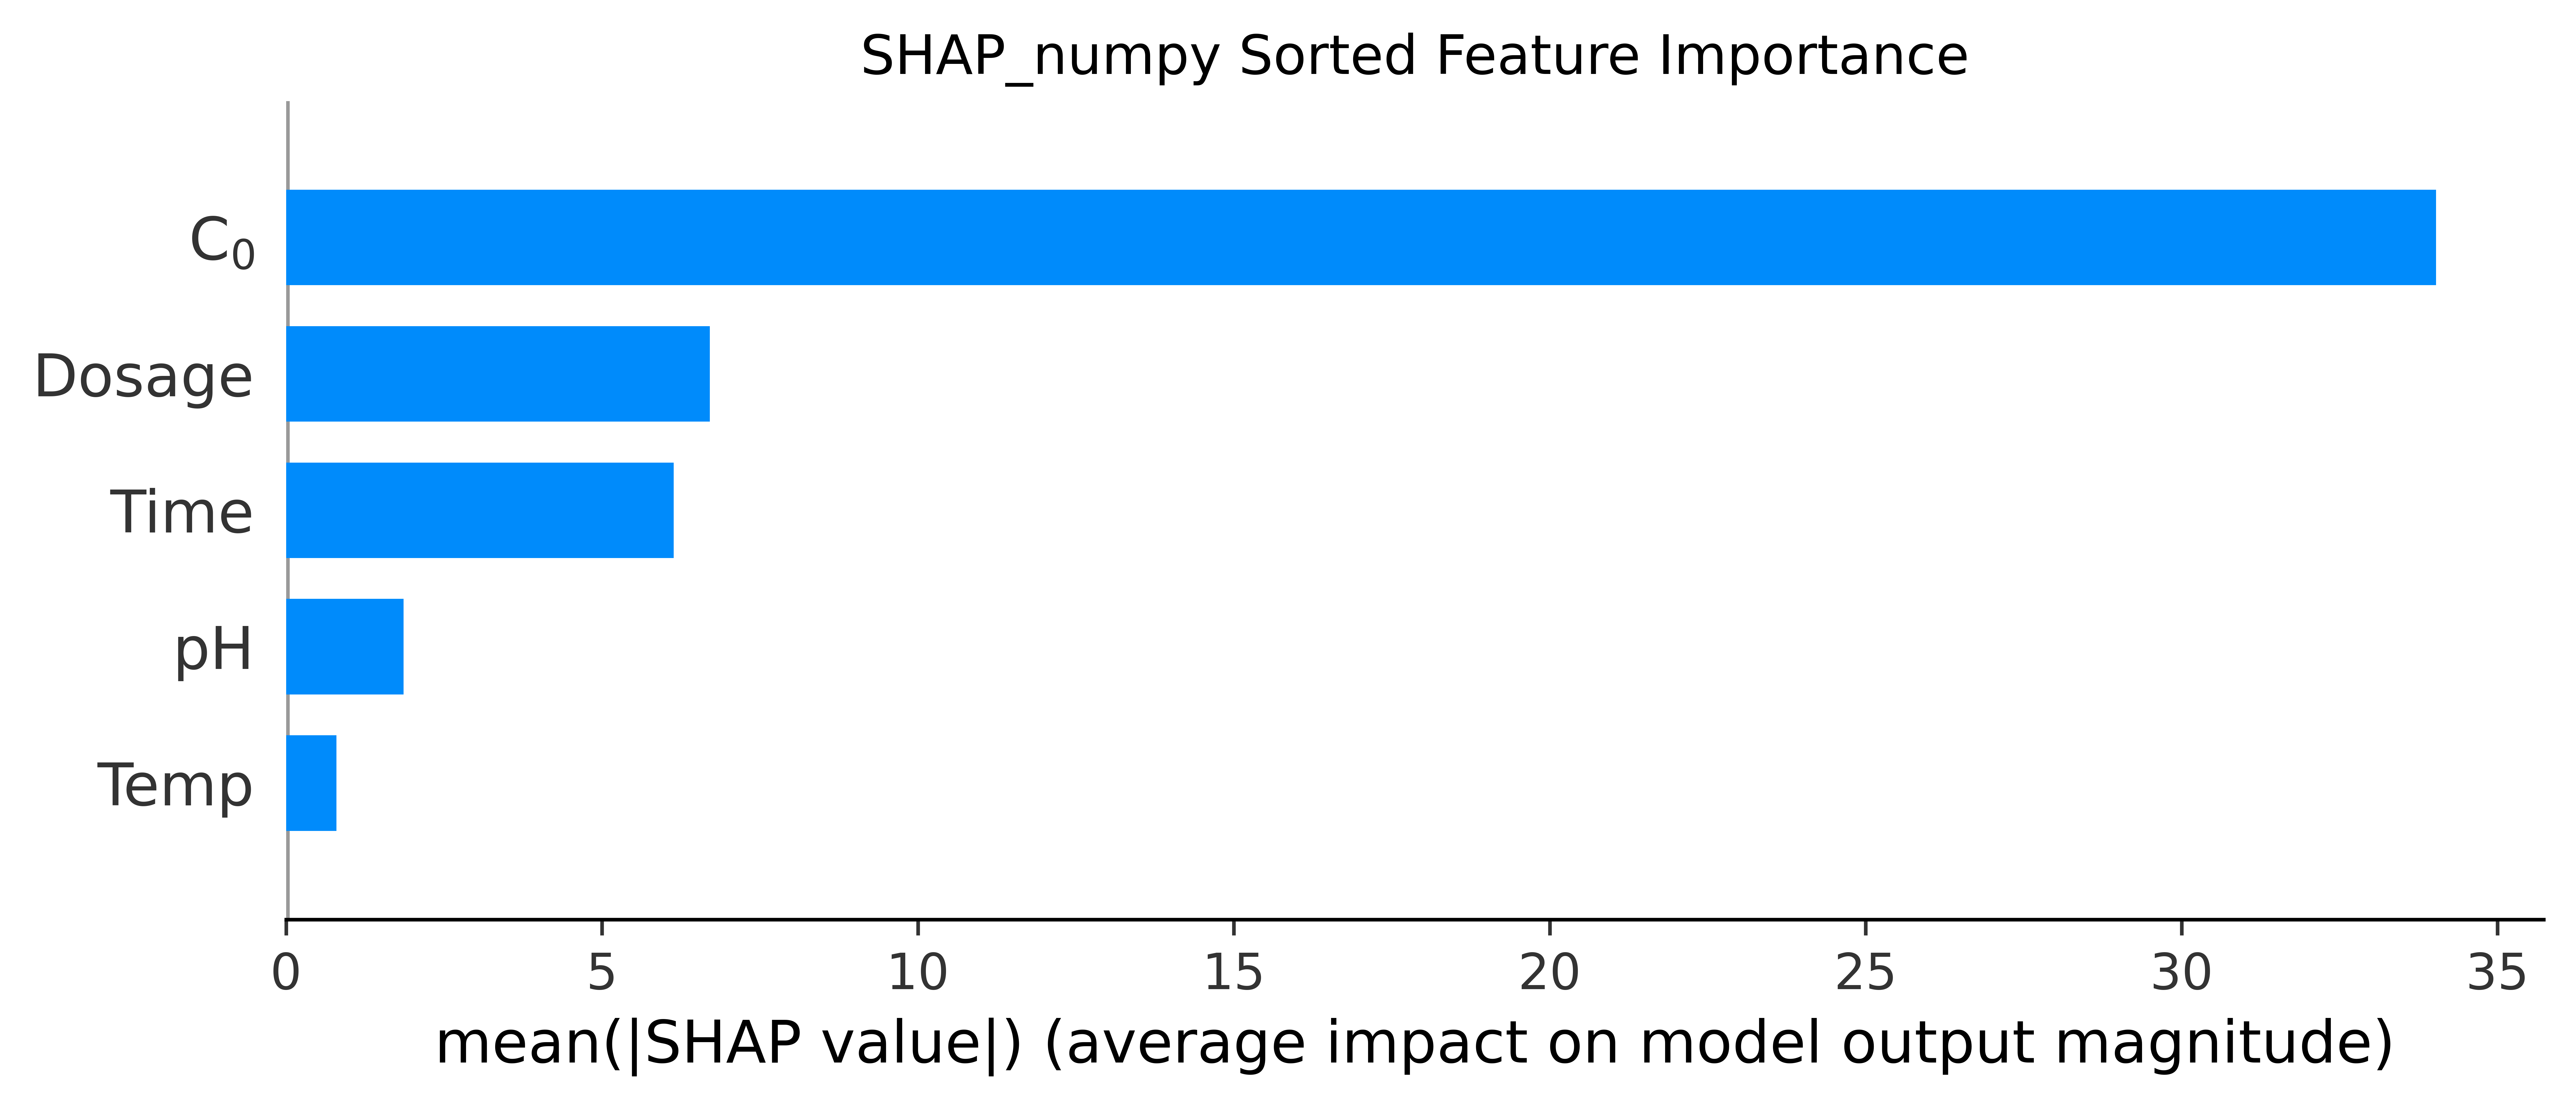

In [11]:
plt.figure(figsize=(10, 5), dpi=1200)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP_numpy Sorted Feature Importance')
plt.tight_layout()
plt.savefig("2.pdf", format='pdf',bbox_inches='tight')
plt.show()

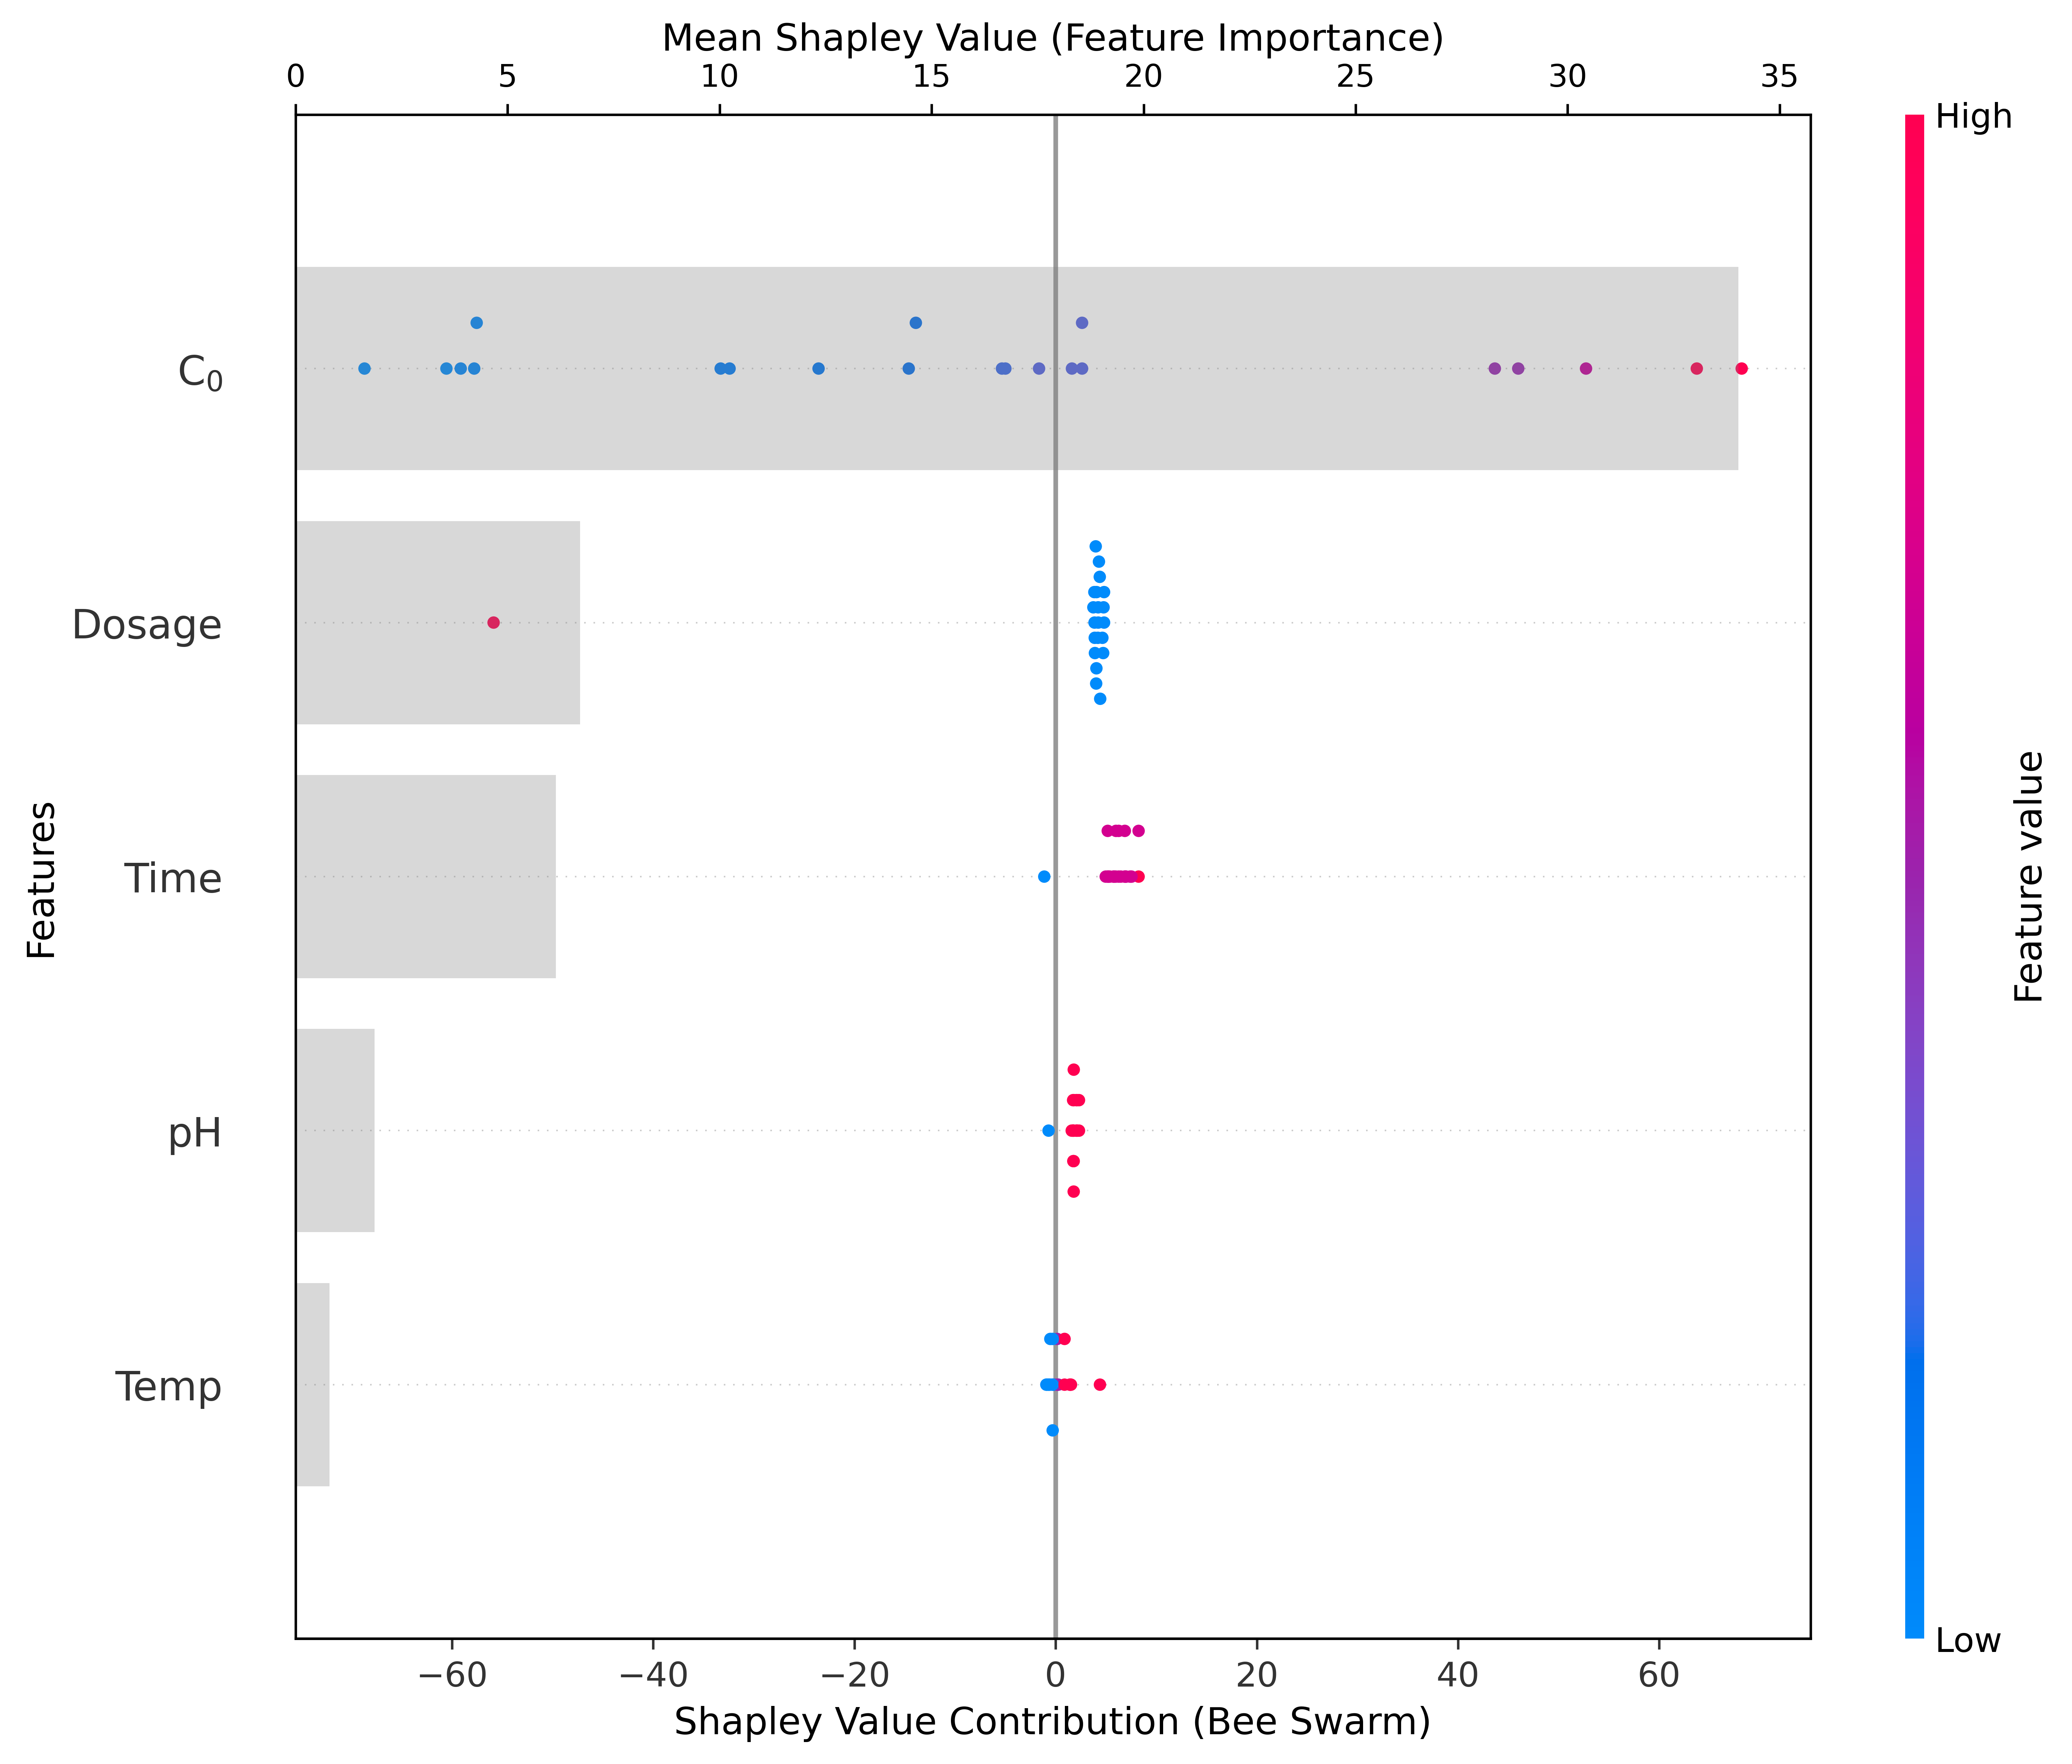

In [12]:
import shap
import matplotlib.pyplot as plt

# 创建图像和主轴
fig, ax1 = plt.subplots(figsize=(10, 8), dpi=600)

# 绘制蜂群图在左侧坐标轴
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns,
                  plot_type="dot", show=False, color_bar=True, plot_size=None)

# 获取当前轴，并调整蜂群图的位置
ax1 = plt.gca()
ax1.set_xlabel('Shapley Value Contribution (Bee Swarm)', fontsize=12)
ax1.set_ylabel('Features', fontsize=12)

# 创建右侧坐标轴用于条形图
ax2 = ax1.twiny()

# 计算特征重要性
shap_importance = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(shap_importance)
sorted_features = X_test.columns[sorted_idx]
sorted_importance = shap_importance[sorted_idx]

# 绘制条形图在右侧坐标轴
ax2.barh(sorted_features, sorted_importance, alpha=0.3, color='gray')
ax2.set_xlabel('Mean Shapley Value (Feature Importance)', fontsize=12)

# 设置右侧坐标轴位置到顶部
ax2.xaxis.set_label_position('top')
ax2.xaxis.tick_top()

# 调整布局
fig.tight_layout()

# 保存图像
plt.savefig("shap_overlay_separated.pdf", format='pdf', bbox_inches='tight')
plt.show()


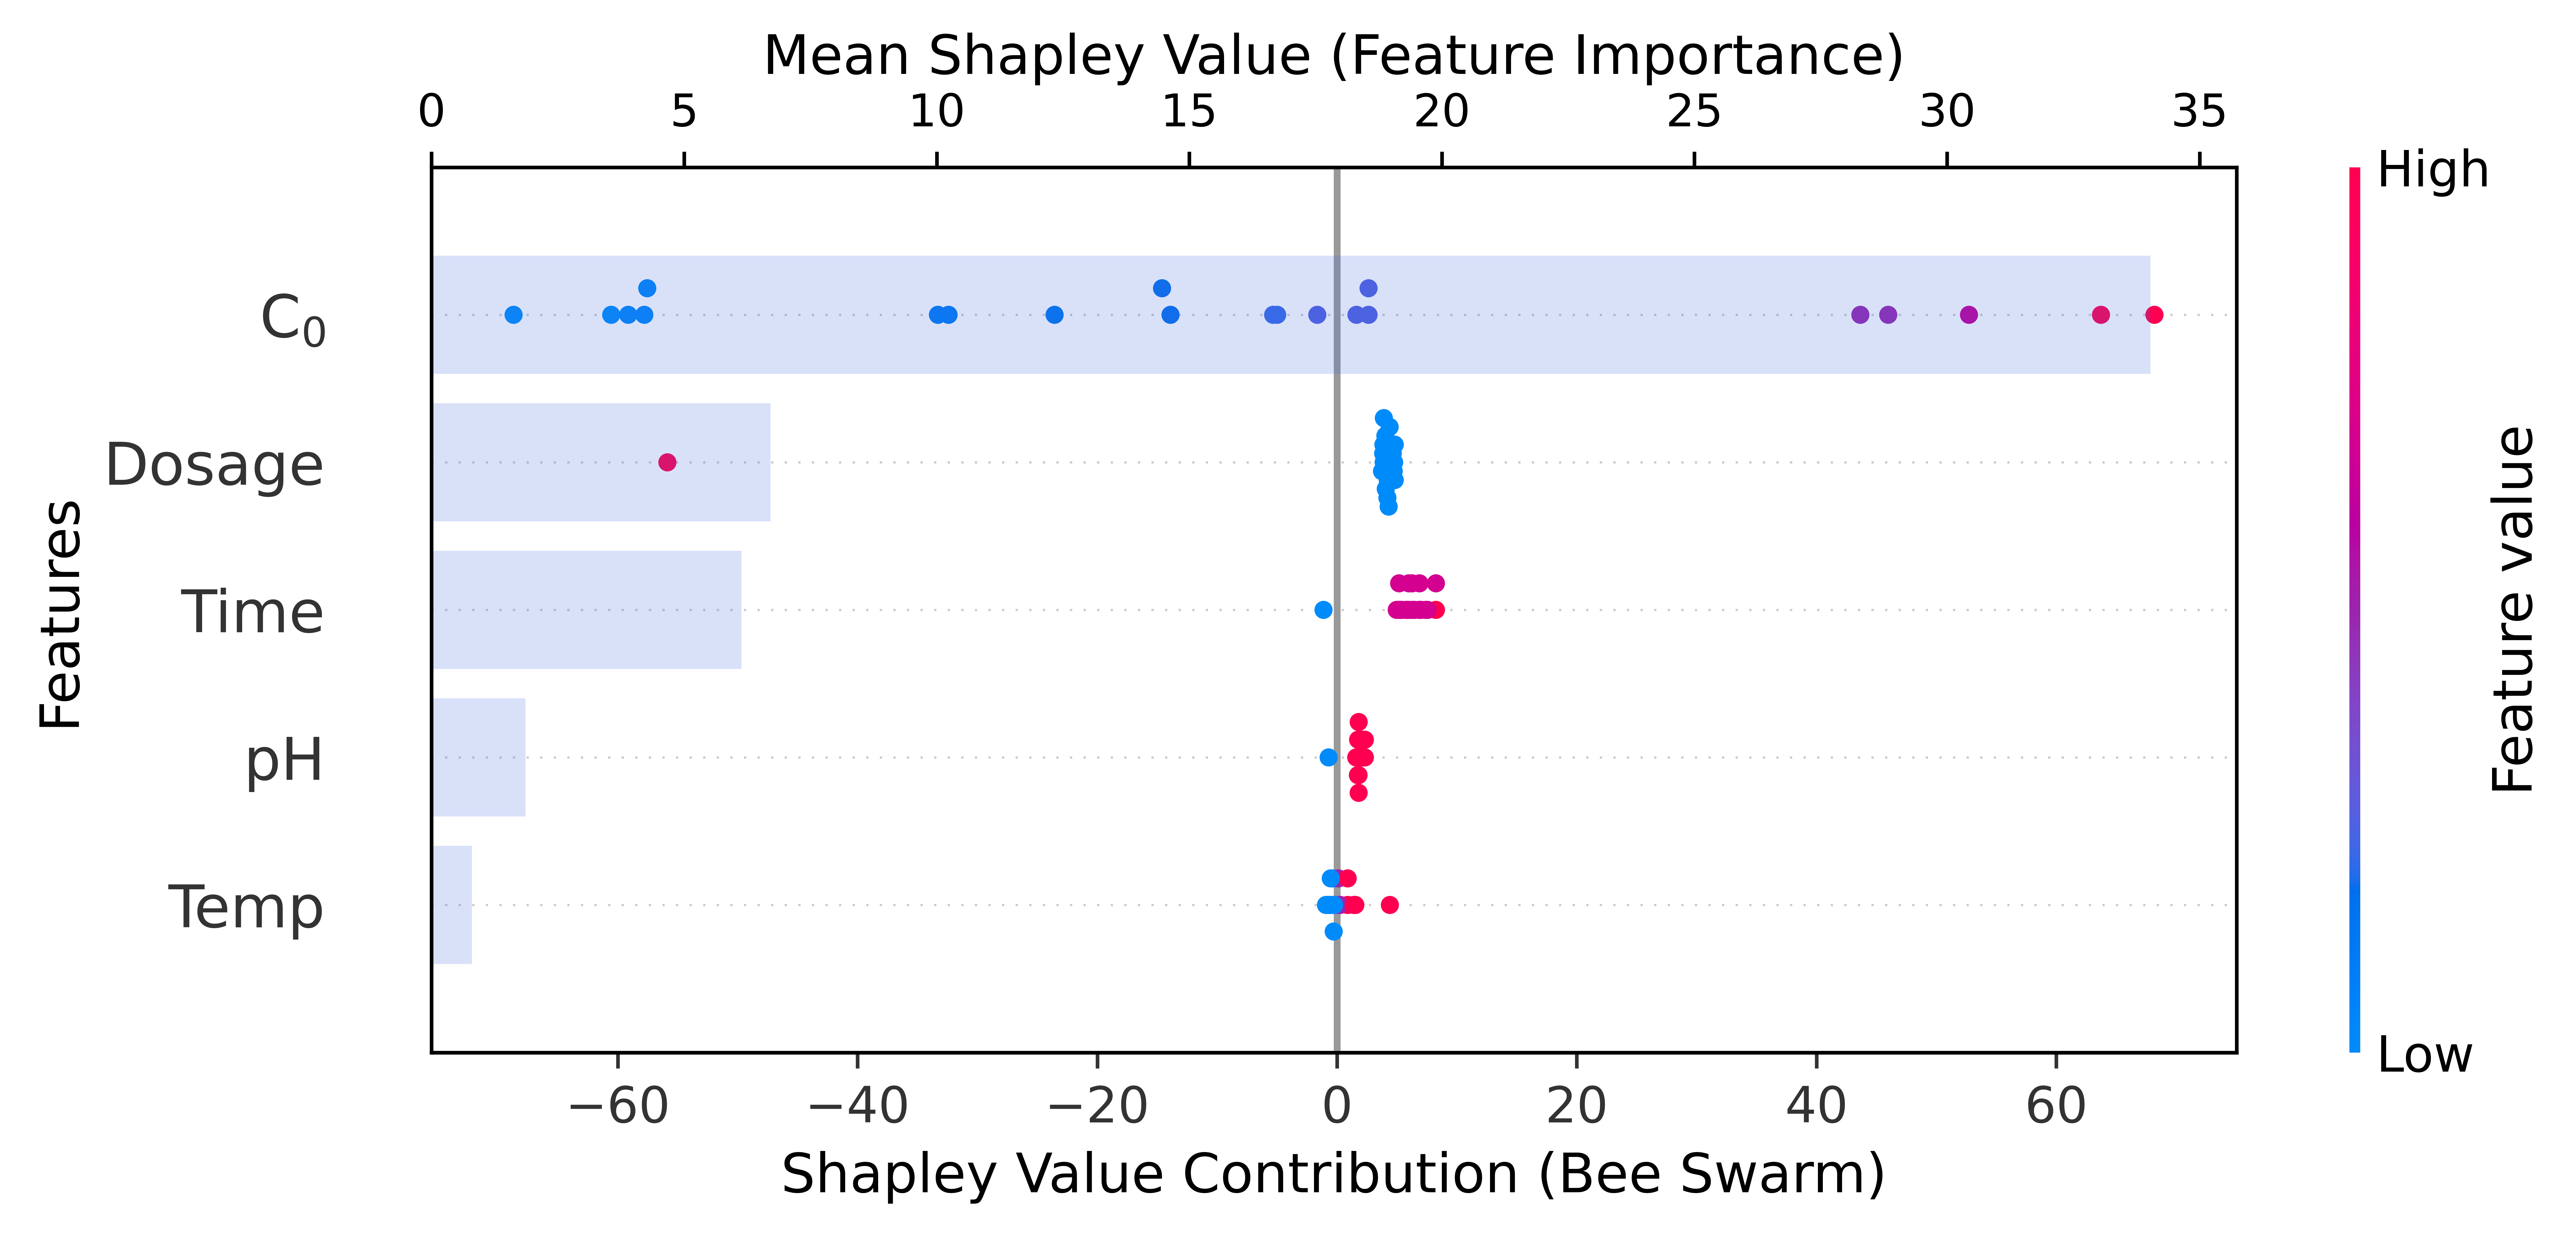

In [13]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 创建主图（蜂巢图）
fig, ax1 = plt.subplots(figsize=(10, 8), dpi=1200)

# 绘制蜂巢图，并保留热度条
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns,
                  plot_type="dot", show=False, color_bar=True)

# 调整图表位置，留出右侧空间放热度条
plt.gca().set_position([0.2, 0.2, 0.6, 0.65])

# 获取当前的y轴
ax1 = plt.gca()

# 创建共享y轴的顶部x轴用于绘制特征贡献条形图
ax2 = ax1.twiny()

# 计算并排序特征的重要性
shap_importance = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(shap_importance)
sorted_features = X_test.columns[sorted_idx]
sorted_importance = shap_importance[sorted_idx]

# 绘制条形图
ax2.barh(sorted_features, sorted_importance, color='royalblue', alpha=0.2)

# 调整顶部x轴的位置与大小
ax2.set_position([0.2, 0.2, 0.6, 0.65])

# 在顶部X轴下方添加一条横线（注意y值需要对应实际位置，可根据特征数调整）
# ax2.axhline(y=len(sorted_features)-0.5, color='gray', linestyle='-', linewidth=1)

# 设置x轴的标签
ax1.set_xlabel('Shapley Value Contribution (Bee Swarm)', fontsize=12)
ax2.set_xlabel('Mean Shapley Value (Feature Importance)', fontsize=12)

# 移动顶部X轴的刻度与标签位置
ax2.xaxis.set_label_position('top')
ax2.xaxis.tick_top()

# 设置y轴的标签
ax1.set_ylabel('Features', fontsize=12)

# 优化布局
plt.tight_layout()

# 保存结果为PDF
plt.savefig("shap_overlay_refined.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [14]:
# 假设 X_test 是一个 Pandas DataFrame
feature_importance = np.mean(np.abs(shap_values), axis=0)

# 创建一个 DataFrame，将列名设置为 X_test 的特征名
feature_importance_df = pd.DataFrame({
    'Feature': X_test.columns,  # 使用 X_test 的特征名
    'Importance': feature_importance  # 对应的均值
}).sort_values(by='Importance', ascending=False)  # 按重要性降序排序
feature_importance_df

,Feature,Importance
1,C$_0$,34.029245
2,Dosage,6.708364
4,Time,6.136047
0,pH,1.859084
3,Temp,0.798260


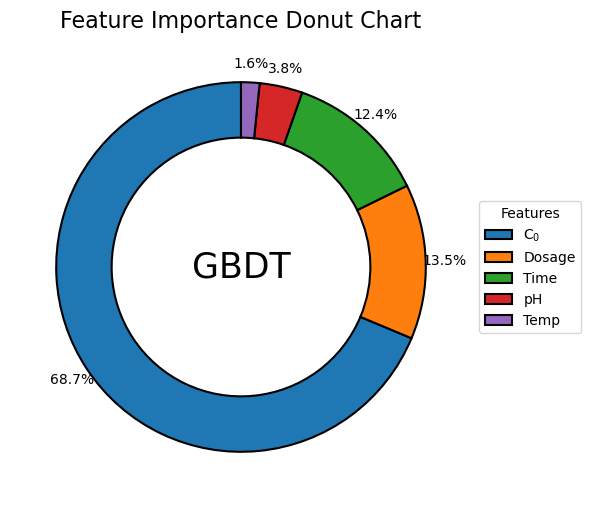

In [15]:
# 提取特征名和重要性值
features = feature_importance_df['Feature']
importances = feature_importance_df['Importance']

# 绘制环形图
fig, ax = plt.subplots(figsize=(8, 6))

# 环形图
wedges, texts = ax.pie(
    importances,
    startangle=90,
    wedgeprops=dict(width=0.3, edgecolor='black', linewidth=1.5),  # 设置区域包裹为黑色线条
    labels=None  # 不在区域中显示标签
)

# 添加百分比到区域外部
for wedge, importance in zip(wedges, importances):
    angle = (wedge.theta2 - wedge.theta1) / 2 + wedge.theta1  # 计算区域角度
    x = 1.1 * wedge.r * np.cos(np.radians(angle))  # 调整百分比位置 (x 坐标)
    y = 1.1 * wedge.r * np.sin(np.radians(angle))  # 调整百分比位置 (y 坐标)
    ax.text(x, y, f'{importance / sum(importances):.1%}', ha='center', va='center', fontsize=10)

# 添加中心文本
ax.text(0, 0, 'GBDT', ha='center', va='center', fontsize=25)

# 设置图例
ax.legend(
    wedges, features,
    title="Features",
    loc="center left",
    bbox_to_anchor=(1, 0.5),  # 图例位置
    fontsize=10
)

# 设置圆形比例
ax.set_aspect('equal')  # 确保环形图是圆形
plt.title('Feature Importance Donut Chart', fontsize=16)
plt.savefig("4.pdf", format='pdf', bbox_inches='tight')
plt.show()

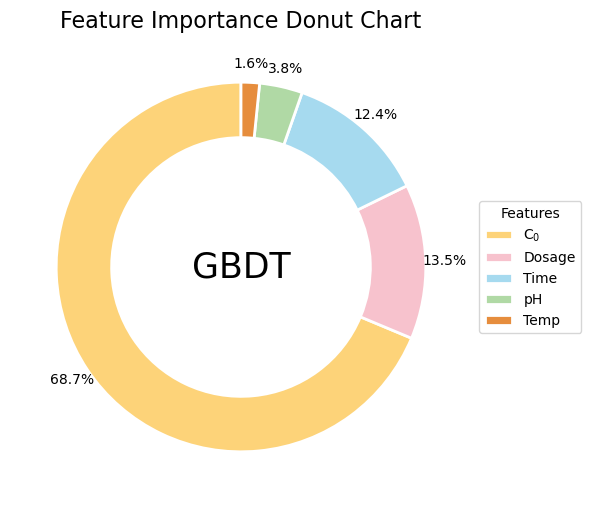

In [29]:
# 提取特征名和重要性值
features = feature_importance_df['Feature']
importances = feature_importance_df['Importance']

# 原始颜色列表
colors_original = ['#FDD379', '#F7C2CD', '#A6DAEF', '#B0D9A5', '#E68D3D']

# 新增颜色
colors_preferred = ['#ECC4C1', '#C0D5EB', '#DFECD5', '#C2E1E2', '#C4C5E1', '#FF39A2']

# 合并原始颜色和新增颜色
colors = colors_original + colors_new

# 确保颜色数量与特征数量一致（截取匹配数量）
colors = colors[:len(features)]

# 绘制环形图
fig, ax = plt.subplots(figsize=(8, 6))

# 环形图
wedges, texts = ax.pie(
    importances,
    startangle=90,
    wedgeprops=dict(width=0.3, edgecolor='white', linewidth=2),  # 设置间隔
    colors=colors,  # 使用扩展后的颜色
    labels=None  # 不在区域中显示标签
)

# 添加百分比到区域外部
for wedge, importance in zip(wedges, importances):
    angle = (wedge.theta2 - wedge.theta1) / 2 + wedge.theta1  # 计算区域角度
    x = 1.1 * wedge.r * np.cos(np.radians(angle))  # 调整百分比位置 (x 坐标)
    y = 1.1 * wedge.r * np.sin(np.radians(angle))  # 调整百分比位置 (y 坐标)
    ax.text(x, y, f'{importance / sum(importances):.1%}', ha='center', va='center', fontsize=10)

# 添加中心文本
ax.text(0, 0, 'GBDT', ha='center', va='center', fontsize=25)

# 设置图例
ax.legend(
    wedges, features,
    title="Features",
    loc="center left",
    bbox_to_anchor=(1, 0.5),  # 图例位置
    fontsize=10
)

# 设置圆形比例
ax.set_aspect('equal')  # 确保环形图是圆形
plt.title('Feature Importance Donut Chart', fontsize=16)
plt.savefig("5.pdf", format='pdf', bbox_inches='tight')
plt.show()